In [13]:
import pandas as pd
import scipy.stats as stats
import numpy as np

In [15]:
bm = pd.read_csv("stats_bm.csv")
bm

,Unnamed: 0,night.mmdd,count_small,count_medium-small,count_medium-large,count_large,total,bm_small,bm_medium-small,bm_medium-large,bm_large,bm_total,site
0,0,611,57,74,4,5,140,156.75,3996,1444,2090,7686.75,WS1
1,1,620,39,40,7,7,93,107.25,2160,2527,2926,7720.25,WS1
2,2,628,28,23,7,6,64,77.00,1242,2527,2508,6354.00,WS1
3,3,705,44,11,5,0,60,121.00,594,1805,0,2520.00,WS1
4,4,712,28,23,3,0,54,77.00,1242,1083,0,2402.00,WS1
5,5,720,20,10,2,0,32,55.00,540,722,0,1317.00,WS1
6,6,724,15,6,4,1,26,41.25,324,1444,418,2227.25,WS1
7,7,802,15,5,1,0,21,41.25,270,361,0,672.25,WS1
8,8,816,42,14,1,0,57,115.50,756,361,0,1232.50,WS1
9,9,819,44,9,2,0,55,121.00,486,722,0,1329.00,WS1


In [18]:
stats = pd.read_csv("stats.csv")
stats = stats.rename(columns={'night.mmdd': 'night'})
stats["night"] = stats["night"].astype("category")
stats["site"] = stats["site"].astype("category")
stats["count_small"] = stats["count_small"].astype(float)
stats["count_medium-small"] = stats["count_medium-small"].astype(float)
stats["count_medium-large"] = stats["count_medium-large"].astype(float)
stats["count_large"] = stats["count_large"].astype(float)
stats = stats[["night","site","count_small", "count_medium-small","count_medium-large","count_large"]]

size_cols = [
    "count_small",
    "count_medium-small",
    "count_medium-large",
    "count_large"
]
stats["total_count"] = stats[size_cols].sum(axis=1)

stats["bm_total"] = bm["bm_total"].astype(float)
stats

,night,site,count_small,count_medium-small,count_medium-large,count_large,total_count,bm_total
0,611,WS1,7.549834,8.602325,2.000000,2.236068,20.388228,7686.75
1,620,WS1,6.244998,6.324555,2.645751,2.645751,17.861056,7720.25
2,628,WS1,5.291503,4.795832,2.645751,2.449490,15.182575,6354.00
3,705,WS1,6.633250,3.316625,2.236068,0.000000,12.185942,2520.00
4,712,WS1,5.291503,4.795832,1.732051,0.000000,11.819385,2402.00
5,720,WS1,4.472136,3.162278,1.414214,0.000000,9.048627,1317.00
6,724,WS1,3.872983,2.449490,2.000000,1.000000,9.322473,2227.25
7,802,WS1,3.872983,2.236068,1.000000,0.000000,7.109051,672.25
8,816,WS1,6.480741,3.741657,1.000000,0.000000,11.222398,1232.50
9,819,WS1,6.633250,3.000000,1.414214,0.000000,11.047463,1329.00


In [20]:
import pandas as pd
# import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

# replace these with your actual sqrt column names
response_cols = [
    "count_small",
    "count_medium-small",
    "count_medium-large",
    "count_large",
    "bm_total"
]

for col in response_cols:
    print("\n==============================")
    print(col)
    print("==============================")

    model = smf.ols(
        f"{col} ~ C(site) + C(night)",
        data=stats
    ).fit()

    anova = anova_lm(model, typ=2)
    print(anova)


count_small
             sum_sq    df         F    PR(>F)
C(site)   11.802511   4.0  2.968168  0.032742
C(night)  91.958985  13.0  7.115819  0.000002
Residual  34.793167  35.0       NaN       NaN

count_medium-small


PatsyError: Error evaluating factor: NameError: name 'count_medium' is not defined
    count_medium-small ~ C(site) + C(night)
    ^^^^^^^^^^^^

## Hypothesis Testing By Site

Control Variable: Site	
Ho: equal	
Ha: unequal	
Hypothesis: Ho, reason: Proof of Concept itself	
alpha: 0.05

ANOVA

In [4]:
from scipy.stats import f_oneway
import pandas as pd
import pprint

groups_by_site = {} # stores total_count of moths per night acroos all classes.

for i, group in stats[["site","total_count"]].groupby("site"):
    groups_by_site.update({str(i):list(group["total_count"])})

print("\n")
print("One site, multiple record dates, irrespective of Size,, Abundance on a Sheet")
print("\n")
pprint.pprint(groups_by_site, width=160)

# print(*groups_by_site.values())
f_stat, p_value = f_oneway(*groups_by_site.values())
print("\n" + "=" * 60)
print("Hypothesis Testing for first control variable: Site")
print("=" * 60 + "\n")
print("F_statistic:", round(f_stat,4))
print("p_value: ", p_value)
print("alpha: ", 0.05 )
print("Is there Much variability across sites: ", p_value < 0.05)



One site, multiple record dates, irrespective of Size,, Abundance on a Sheet


{'WS1': [140.0, 93.0, 64.0, 60.0, 54.0, 32.0, 26.0, 21.0, 57.0, 55.0, 37.0, 43.0, 35.0, 15.0],
 'WS4': [88.0, 30.0, 90.0, 82.0, 37.0, 68.0, 40.0, 54.0, 43.0, 20.0, 19.0],
 'WS5': [169.0, 96.0, 65.0, 63.0, 69.0, 52.0, 65.0, 43.0, 53.0, 18.0, 14.0],
 'WS6low': [85.0, 84.0, 23.0, 36.0, 22.0, 15.0, 27.0, 25.0, 10.0],
 'WS6up': [82.0, 90.0, 35.0, 74.0, 23.0, 11.0, 31.0, 24.0]}

Hypothesis Testing for first control variable: Site

F_statistic: 0.9614
p_value:  0.4372940699386082
alpha:  0.05
Is there Much variability across sites:  False


In [5]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm


model = ols("total_count ~ C(site)", data=stats).fit()
anova_table = anova_lm(model, typ=2)

print("\n" + "=" * 60)
print("Hypothesis Testing for first control variable: Site")
print("=" * 60 + "\n")

anova_table


Hypothesis Testing for first control variable: Site



,sum_sq,df,F,PR(>F)
C(site),4086.250061,4.0,0.961406,0.437294
Residual,51003.448052,48.0,NaN,NaN


In [7]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm


model = ols("count_small ~ C(site)", data=stats).fit()
anova_table = anova_lm(model, typ=2)

print("\n" + "=" * 60)
print("Hypothesis Testing for first control variable: Site")
print("=" * 60 + "\n")

anova_table


Hypothesis Testing for first control variable: Site



,sum_sq,df,F,PR(>F)
C(site),1891.702677,4.0,1.596878,0.190424
Residual,14215.504870,48.0,NaN,NaN


In [10]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm


model = ols("Q('count_medium-small') ~ C(site)", data=stats).fit()
anova_table = anova_lm(model, typ=2)

print("\n" + "=" * 60)
print("Hypothesis Testing for first control variable: Site")
print("=" * 60 + "\n")
anova_table


Hypothesis Testing for first control variable: Site



,sum_sq,df,F,PR(>F)
C(site),626.270376,4.0,0.645998,0.632412
Residual,11633.540945,48.0,NaN,NaN


In [11]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm


model = ols("Q('count_medium-large') ~ C(site)", data=stats).fit()
anova_table = anova_lm(model, typ=2)

print("\n" + "=" * 60)
print("Hypothesis Testing for first control variable: Site")
print("=" * 60 + "\n")
anova_table


Hypothesis Testing for first control variable: Site



,sum_sq,df,F,PR(>F)
C(site),30.962754,4.0,1.557323,0.20091
Residual,238.584416,48.0,NaN,NaN


In [12]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm


model = ols("Q('count_large') ~ C(site)", data=stats).fit()
anova_table = anova_lm(model, typ=2)

print("\n" + "=" * 60)
print("Hypothesis Testing for first control variable: Site")
print("=" * 60 + "\n")
anova_table


Hypothesis Testing for first control variable: Site



,sum_sq,df,F,PR(>F)
C(site),9.080645,4.0,0.421716,0.792172
Residual,258.391053,48.0,NaN,NaN


END OF SIZEWISE, ANOVA ON SITE

MANOVA

In [78]:
from statsmodels.multivariate.manova import MANOVA

maov = MANOVA.from_formula(
    'count_small + Q("count_medium-small") + Q("count_medium-large") + count_large ~ C(site) + C(night)',
    data=stats
)
print("\n" + "=" * 60)
print("Hypothesis Testing for first control variable - Site" + '\n' + "Controling for in Night")
print("=" * 60 + "\n")

print(maov.mv_test())


Hypothesis Testing for first control variable - Site
Controling for in Night

                   Multivariate linear model
                                                               
---------------------------------------------------------------
          Intercept        Value  Num DF  Den DF F Value Pr > F
---------------------------------------------------------------
             Wilks' lambda 0.0995 4.0000 32.0000 72.3920 0.0000
            Pillai's trace 0.9005 4.0000 32.0000 72.3920 0.0000
    Hotelling-Lawley trace 9.0490 4.0000 32.0000 72.3920 0.0000
       Roy's greatest root 9.0490 4.0000 32.0000 72.3920 0.0000
---------------------------------------------------------------
                                                               
---------------------------------------------------------------
         C(site)         Value   Num DF  Den DF  F Value Pr > F
---------------------------------------------------------------
           Wilks' lambda 0.5427 16.0000  98.

## Hypothesis Testing by Night

In [79]:
from scipy.stats import f_oneway
import pandas as pd
import pprint

groups_by_night = {} # stores total_count of moths per night acroos all classes.

for i, group in stats[["night", "site", "total_count"]].groupby("night"):
    groups_by_night.update({str(i):list(group["total_count"])})

print("\n")
print("One night, multiple record sites, irrespective of size, Abundance on a Sheet")
print("\n")
pprint.pprint(groups_by_night, width=160)

f_stat, p_value = f_oneway(*groups_by_night.values())
print("\n" + "=" * 60)
print("Hypothesis Testing for Second control variable: Night")
print("=" * 60 + "\n")
print("F_statistic:", round(f_stat,4))
print("p_value: ", p_value)
print("alpha: ", 0.05 )
print("Is there Much variability across nights: ", p_value < 0.05)



One night, multiple record sites, irrespective of size, Abundance on a Sheet


{'611': [140.0, 88.0, 169.0, 82.0],
 '620': [93.0, 96.0, 90.0],
 '628': [64.0, 30.0, 65.0, 85.0, 35.0],
 '705': [60.0, 90.0, 63.0, 84.0, 74.0],
 '712': [54.0, 82.0, 69.0],
 '720': [32.0, 37.0, 52.0, 23.0],
 '724': [26.0, 68.0, 65.0, 36.0, 23.0],
 '802': [21.0, 22.0, 11.0],
 '816': [57.0, 43.0, 31.0],
 '819': [55.0, 40.0, 53.0],
 '904': [37.0, 54.0, 15.0],
 '909': [43.0, 43.0, 27.0],
 '923': [35.0, 20.0, 18.0, 25.0, 24.0],
 '930': [15.0, 19.0, 14.0, 10.0]}

Hypothesis Testing for Second control variable: Night

F_statistic: 10.2884
p_value:  6.57966893750658e-09
alpha:  0.05
Is there Much variability across nights:  True


In [112]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm


model = ols("total_count ~ C(night)", data=stats).fit()
anova_table = anova_lm(model, typ=2)

print("\n" + "=" * 60)
print("Hypothesis Testing for first control variable: Night")
print("=" * 60 + "\n")

anova_table


Hypothesis Testing for first control variable: Night



,sum_sq,df,F,PR(>F)
C(night),42652.614780,13.0,10.288413,6.579669e-09
Residual,12437.083333,39.0,NaN,NaN


In [13]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm


model = ols("Q('count_small') ~ C(night)", data=stats).fit()
anova_table = anova_lm(model, typ=2)

print("\n" + "=" * 60)
print("Hypothesis Testing for first control variable: Night")
print("=" * 60 + "\n")

anova_table


Hypothesis Testing for first control variable: Night



,sum_sq,df,F,PR(>F)
C(night),10331.790881,13.0,5.366777,0.000021
Residual,5775.416667,39.0,NaN,NaN


In [14]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm


model = ols("Q('count_medium-small') ~ C(night)", data=stats).fit()
anova_table = anova_lm(model, typ=2)

print("\n" + "=" * 60)
print("Hypothesis Testing for first control variable: Night")
print("=" * 60 + "\n")

anova_table


Hypothesis Testing for first control variable: Night



,sum_sq,df,F,PR(>F)
C(night),10170.977987,13.0,14.607644,3.884668e-11
Residual,2088.833333,39.0,NaN,NaN


In [15]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm


model = ols("Q('count_medium-large') ~ C(night)", data=stats).fit()
anova_table = anova_lm(model, typ=2)

print("\n" + "=" * 60)
print("Hypothesis Testing for first control variable: Night")
print("=" * 60 + "\n")

anova_table


Hypothesis Testing for first control variable: Night



,sum_sq,df,F,PR(>F)
C(night),173.563836,13.0,5.424812,0.000019
Residual,95.983333,39.0,NaN,NaN


In [16]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm


model = ols("Q('count_large') ~ C(night)", data=stats).fit()
anova_table = anova_lm(model, typ=2)

print("\n" + "=" * 60)
print("Hypothesis Testing for first control variable: Night")
print("=" * 60 + "\n")

anova_table


Hypothesis Testing for first control variable: Night



,sum_sq,df,F,PR(>F)
C(night),232.588365,13.0,20.002822,2.701106e-13
Residual,34.883333,39.0,NaN,NaN


## Hypothesis Testing by Size

MULTIPLE OPTIONS OF GROUPING/AGGREGATE VALUES FOR SIZEBINS, 

1. Total Value across Sites for each Night. (imo not a valid form of distribution, total is highly dependent on days active) 
2. Total Value across Nights for each Site. (imo not a valid form of distribution, total is highly dependent on days active)
3. Average Value across Sites for each Night. - 17 values, one for each night, using sites to average, better also because we failed to reject the null Hypothesis!
4. Average Value across Nights, for each Site. - 4 values, 1 for each site. i think bad representation, since there is variation among sites and we rejected the null hypothesis 

Proceeding with option 3.

In [98]:
# sites = ["WS1", "WS4", "WS5","WS6low", "WS6up"]
sizes = ["count_small","count_medium-small","count_medium-large", "count_large"]
groups_by_size = {}

for i, group in stats[["night",*sizes]].groupby("night"):
    # pprint.pprint(i)
    # pprint.pprint(group)
    for size in sizes:
        if size in groups_by_size:
            groups_by_size[size].append(np.mean(group[size]))
        else:
            groups_by_size[size] = [np.mean(group[size])]

print("\n")
print("One size, aveg on multiple record sites, for each night, condiering each night as ONE big sheet.")
print("\n")

pprint.pprint(groups_by_size, width= 350)


f_stat, p_value = f_oneway(*groups_by_size.values())
print("\n" + "=" * 60)
print("Hypothesis Testing for Second control variable: Size")
print("=" * 60 + "\n")
print("F_statistic:", round(f_stat,4))
print("p_value: ", p_value)
print("alpha: ", 0.05 )
print("Is there Much variability across Sizes: ", p_value < 0.05)




One size, aveg on multiple record sites, for each night, condiering each night as ONE big sheet.


{'count_large': [6.75, 5.333333333333333, 2.6, 0.8, 0.3333333333333333, 0.0, 0.2, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 'count_medium-large': [4.75, 6.666666666666667, 5.0, 4.2, 3.6666666666666665, 1.25, 2.2, 1.0, 1.6666666666666667, 1.3333333333333333, 0.3333333333333333, 1.0, 2.2, 0.75],
 'count_medium-small': [58.0, 36.0, 20.8, 16.0, 19.333333333333332, 8.25, 11.6, 5.333333333333333, 15.333333333333334, 11.333333333333334, 6.0, 12.333333333333334, 7.0, 7.25],
 'count_small': [50.25, 45.0, 27.4, 53.2, 45.0, 26.5, 29.6, 11.666666666666666, 26.666666666666668, 36.666666666666664, 29.0, 24.333333333333332, 15.2, 6.5]}

Hypothesis Testing for Second control variable: Size

F_statistic: 25.5906
p_value:  2.6297150660229885e-10
alpha:  0.05
Is there Much variability across Sizes:  True


In [110]:
rows = []

for size, values in groups_by_size.items():
    for value in values:
        rows.append({
            "size": size,
            "count": value
        })

anova_df = pd.DataFrame(rows)
anova_df["count"] = anova_df["count"].astype(float)
anova_df["size"] = anova_df["size"].astype("category")
display(anova_df)

model = ols("count ~ C(size)", data=anova_df).fit()
anova_table = anova_lm(model, typ=2)

anova_table

,size,count
0,count_small,50.250000
1,count_small,45.000000
2,count_small,27.400000
3,count_small,53.200000
4,count_small,45.000000
5,count_small,26.500000
6,count_small,29.600000
7,count_small,11.666667
8,count_small,26.666667
9,count_small,36.666667


,sum_sq,df,F,PR(>F)
C(size),7970.694896,3.0,25.590623,2.629715e-10
Residual,5398.802282,52.0,NaN,NaN


In [5]:
import pandas as pd
stats_bm = pd.read_csv("stats_bm.csv")
stats_bm = stats_bm.rename(columns={'night.mmdd': 'night'})
stats_bm["site"] = stats_bm["site"].astype("category")
stats_bm["night"] = stats_bm["night"].astype("category")
stats_bm["bm_total"] = stats_bm["bm_total"].astype("float")
stats_bm

,Unnamed: 0,night,count_small,count_medium-small,count_medium-large,count_large,total,bm_small,bm_medium-small,bm_medium-large,bm_large,bm_total,site
0,0,611,57,74,4,5,140,156.75,3996,1444,2090,7686.75,WS1
1,1,620,39,40,7,7,93,107.25,2160,2527,2926,7720.25,WS1
2,2,628,28,23,7,6,64,77.00,1242,2527,2508,6354.00,WS1
3,3,705,44,11,5,0,60,121.00,594,1805,0,2520.00,WS1
4,4,712,28,23,3,0,54,77.00,1242,1083,0,2402.00,WS1
5,5,720,20,10,2,0,32,55.00,540,722,0,1317.00,WS1
6,6,724,15,6,4,1,26,41.25,324,1444,418,2227.25,WS1
7,7,802,15,5,1,0,21,41.25,270,361,0,672.25,WS1
8,8,816,42,14,1,0,57,115.50,756,361,0,1232.50,WS1
9,9,819,44,9,2,0,55,121.00,486,722,0,1329.00,WS1


In [6]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm


model = ols("bm_total ~ C(site)", data=stats_bm).fit()
anova_table = anova_lm(model, typ=2)

print("\n" + "=" * 60)
print("Hypothesis Testing for first control variable: Site")
print("=" * 60 + "\n")

anova_table


Hypothesis Testing for first control variable: Site



,sum_sq,df,F,PR(>F)
C(site),1.540664e+07,4.0,0.677651,0.610798
Residual,2.728244e+08,48.0,NaN,NaN


In [8]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm


model = ols("bm_total ~ C(night)", data=stats_bm).fit()
anova_table = anova_lm(model, typ=2)

print("\n" + "=" * 60)
print("Hypothesis Testing for first control variable: night")
print("=" * 60 + "\n")

anova_table


Hypothesis Testing for first control variable: night



,sum_sq,df,F,PR(>F)
C(night),2.495670e+08,13.0,19.364235,4.574122e-13
Residual,3.866411e+07,39.0,NaN,NaN


make table

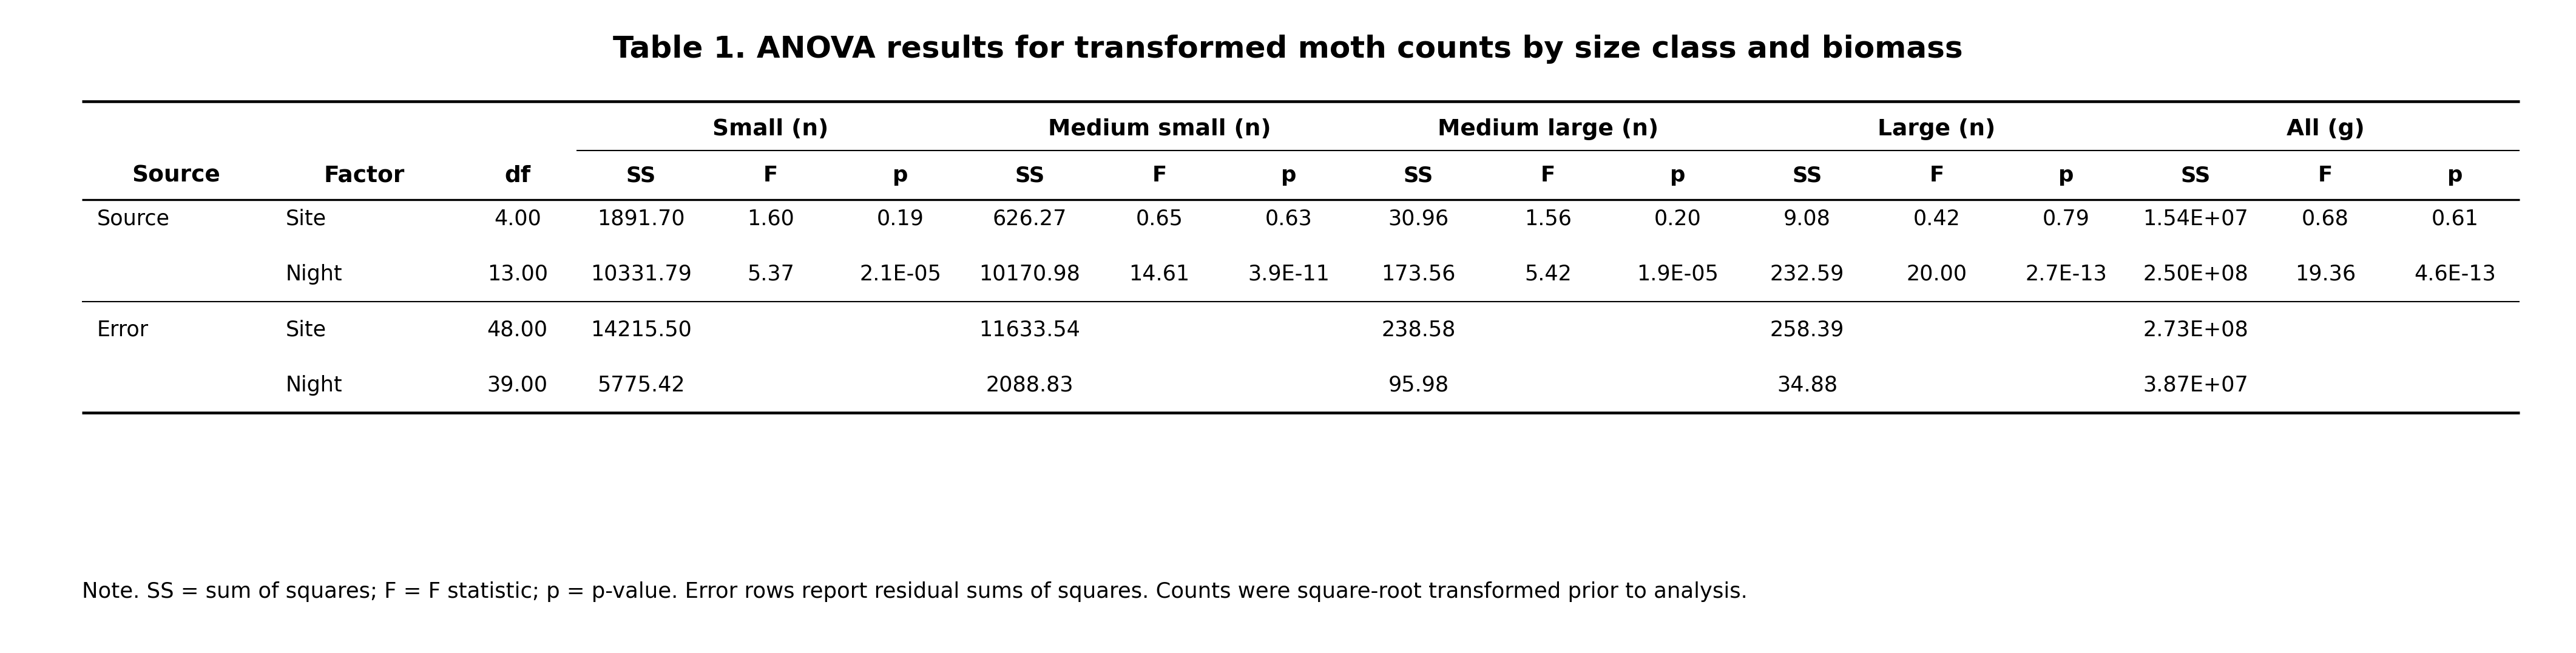

In [12]:
import matplotlib.pyplot as plt

# -----------------------------
# Data
# Removed All (n)
# -----------------------------
rows = [
    ["Source", "Site",  4,
     1891.70, 1.60, "0.19",
     626.27, 0.65, "0.63",
     30.96, 1.56, "0.20",
     9.08, 0.42, "0.79",
     15400000, 0.68, "0.61"],

    ["", "Night", 13,
     10331.79, 5.37, "2.1E-05",
     10170.98, 14.61, "3.9E-11",
     173.56, 5.42, "1.9E-05",
     232.59, 20.00, "2.7E-13",
     250000000, 19.36, "4.6E-13"],

    ["Error", "Site", 48,
     14215.50, "", "",
     11633.54, "", "",
     238.58, "", "",
     258.39, "", "",
     273000000, "", ""],

    ["", "Night", 39,
     5775.42, "", "",
     2088.83, "", "",
     95.98, "", "",
     34.88, "", "",
     38700000, "", ""]
]

group_headers = [
    "Small (n)",
    "Medium small (n)",
    "Medium large (n)",
    "Large (n)",
    "All (g)"
]

sub_headers = ["SS", "F", "p"]

# -----------------------------
# Layout
# -----------------------------
fig, ax = plt.subplots(figsize=(18, 4.4), dpi=300)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

left = 0.025
right = 0.985
top = 0.82

table_width = right - left

# Source, factor, df, then 5 groups × 3 columns
# Made columns fatter by using fewer groups + wider figure
col_widths = [0.08, 0.08, 0.05] + [0.055] * 15

# Normalize to fit page width
scale = table_width / sum(col_widths)
col_widths = [w * scale for w in col_widths]

x_edges = [left]
for w in col_widths:
    x_edges.append(x_edges[-1] + w)

x_centers = [
    (x_edges[i] + x_edges[i + 1]) / 2
    for i in range(len(col_widths))
]

header1_y = top
header2_y = top - 0.075
body_start_y = top - 0.145
row_h = 0.09

# -----------------------------
# Title
# -----------------------------
ax.text(
    0.5, 0.95,
    "Table 1. ANOVA results for transformed moth counts by size class and biomass",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold"
)

# -----------------------------
# Header: first three columns
# -----------------------------
ax.text(x_centers[0], header2_y, "Source",
        ha="center", va="center", fontsize=9, fontweight="bold")

ax.text(x_centers[1], header2_y, "Factor",
        ha="center", va="center", fontsize=9, fontweight="bold")

ax.text(x_centers[2], header2_y, "df",
        ha="center", va="center", fontsize=9, fontweight="bold")

# -----------------------------
# Grouped headers
# -----------------------------
for g, header in enumerate(group_headers):
    start_col = 3 + g * 3
    end_col = start_col + 2

    x_mid = (x_centers[start_col] + x_centers[end_col]) / 2

    ax.text(
        x_mid, header1_y,
        header,
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

    for j, sub in enumerate(sub_headers):
        col = start_col + j
        ax.text(
            x_centers[col], header2_y,
            sub,
            ha="center",
            va="center",
            fontsize=8.5,
            fontweight="bold"
        )

# -----------------------------
# Format helper
# -----------------------------
def fmt_value(x):
    if x == "":
        return ""

    if isinstance(x, str):
        return x

    if abs(x) >= 1_000_000:
        return f"{x:.2E}"

    return f"{x:.2f}"


# -----------------------------
# Body rows
# -----------------------------
for r, row in enumerate(rows):
    y = body_start_y - r * row_h

    for c, value in enumerate(row):
        text = fmt_value(value)

        if c in [0, 1]:
            ha = "left"
            x = x_edges[c] + 0.006
        else:
            ha = "center"
            x = x_centers[c]

        ax.text(
            x, y,
            text,
            ha=ha,
            va="center",
            fontsize=8.4
        )

# -----------------------------
# Booktabs-style horizontal lines
# -----------------------------
top_rule_y = top + 0.045
mid_rule_y = top - 0.115
bottom_rule_y = body_start_y - (len(rows) - 1) * row_h - 0.045
block_rule_y = body_start_y - 1.5 * row_h

ax.hlines(top_rule_y, left, right, linewidth=1.1, color="black")
ax.hlines(mid_rule_y, left, right, linewidth=0.8, color="black")
ax.hlines(block_rule_y, left, right, linewidth=0.5, color="black")
ax.hlines(bottom_rule_y, left, right, linewidth=1.1, color="black")

# Short lines under each grouped header
for g in range(len(group_headers)):
    start_col = 3 + g * 3
    end_col = start_col + 2

    ax.hlines(
        header1_y - 0.035,
        x_edges[start_col],
        x_edges[end_col + 1],
        linewidth=0.5,
        color="black"
    )

# -----------------------------
# Note
# -----------------------------
note = (
    "Note. SS = sum of squares; F = F statistic; p = p-value. "
    "Error rows report residual sums of squares. Counts were square-root transformed prior to analysis."
)

ax.text(
    left, 0.07,
    note,
    ha="left",
    va="center",
    fontsize=8.5
)

# -----------------------------
# Export
# -----------------------------
plt.savefig("anova_grouped_table_no_all_n.png", bbox_inches="tight", dpi=600)
plt.savefig("anova_grouped_table_no_all_n.pdf", bbox_inches="tight")
plt.savefig("anova_grouped_table_no_all_n.svg", bbox_inches="tight")

plt.show()